In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")


In [2]:
# --------------------
# Load data
# --------------------
train_df = pd.read_csv(r'clean_data/cleaned_loans_train.csv')
valid_df = pd.read_csv(r'clean_data/cleaned_loans_valid.csv')
test_df = pd.read_csv(r'clean_data/cleaned_loans_test.csv')

In [3]:
pd.set_option('display.max_columns', None)
train_df.head()

,index,target,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,OriginalDTI,OriginalUPB,OriginalLTV,OriginalInterestRate,Channel,ProductType,PropertyState,PropertyType,PostalCode,LoanPurpose,OriginalLoanTerm,NumberOfBorrowers,SellerName,ServicerName,SuperConformingFlag,ProgramIndicator,PropertyValMethod,BalloonIndicator,0_CurrentActualUPB,0_CurrentInterestRate,0_CurrentNonInterestBearingUPB,0_EstimatedLTV,0_InterestBearingUPB,0_LoanAge,0_MonthlyReportingPeriod,0_RemainingMonthsToLegalMaturity,1_CurrentActualUPB,1_CurrentInterestRate,1_CurrentNonInterestBearingUPB,1_EstimatedLTV,1_InterestBearingUPB,1_LoanAge,1_MonthlyReportingPeriod,1_RemainingMonthsToLegalMaturity,2_CurrentActualUPB,2_CurrentInterestRate,2_CurrentNonInterestBearingUPB,2_EstimatedLTV,2_InterestBearingUPB,2_LoanAge,2_MonthlyReportingPeriod,2_RemainingMonthsToLegalMaturity,3_CurrentActualUPB,3_CurrentInterestRate,3_CurrentNonInterestBearingUPB,3_EstimatedLTV,3_InterestBearingUPB,3_LoanAge,3_MonthlyReportingPeriod,3_RemainingMonthsToLegalMaturity,4_CurrentActualUPB,4_CurrentInterestRate,4_CurrentNonInterestBearingUPB,4_EstimatedLTV,4_InterestBearingUPB,4_LoanAge,4_MonthlyReportingPeriod,4_RemainingMonthsToLegalMaturity,5_CurrentActualUPB,5_CurrentInterestRate,5_CurrentNonInterestBearingUPB,5_EstimatedLTV,5_InterestBearingUPB,5_LoanAge,5_MonthlyReportingPeriod,5_RemainingMonthsToLegalMaturity,6_CurrentActualUPB,6_CurrentInterestRate,6_CurrentNonInterestBearingUPB,6_EstimatedLTV,6_InterestBearingUPB,6_LoanAge,6_MonthlyReportingPeriod,6_RemainingMonthsToLegalMaturity,7_CurrentActualUPB,7_CurrentInterestRate,7_CurrentNonInterestBearingUPB,7_EstimatedLTV,7_InterestBearingUPB,7_LoanAge,7_MonthlyReportingPeriod,7_RemainingMonthsToLegalMaturity,8_CurrentActualUPB,8_CurrentInterestRate,8_CurrentNonInterestBearingUPB,8_EstimatedLTV,8_InterestBearingUPB,8_LoanAge,8_MonthlyReportingPeriod,8_RemainingMonthsToLegalMaturity,9_CurrentActualUPB,9_CurrentInterestRate,9_CurrentNonInterestBearingUPB,9_EstimatedLTV,9_InterestBearingUPB,9_LoanAge,9_MonthlyReportingPeriod,9_RemainingMonthsToLegalMaturity,10_CurrentActualUPB,10_CurrentInterestRate,10_CurrentNonInterestBearingUPB,10_EstimatedLTV,10_InterestBearingUPB,10_LoanAge,10_MonthlyReportingPeriod,10_RemainingMonthsToLegalMaturity,11_CurrentActualUPB,11_CurrentInterestRate,11_CurrentNonInterestBearingUPB,11_EstimatedLTV,11_InterestBearingUPB,11_LoanAge,11_MonthlyReportingPeriod,11_RemainingMonthsToLegalMaturity,12_CurrentActualUPB,12_CurrentInterestRate,12_CurrentNonInterestBearingUPB,12_EstimatedLTV,12_InterestBearingUPB,12_LoanAge,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity,CreditScore_is_outlier,OriginalDTI_is_outlier
0,0.0,0.0,747,202403,N,205402,NaN,0,1,P,67,26,82000,67,8.000,R,FRM,KS,MH,67600,P,360,1,Other sellers,Other servicers,N,Unknown,2,Unknown,82000.0,8.000,0.0,999,82000.0,0,202402,360,82000.0,8.000,0.0,999,82000.0,1,202403,359,82000.0,8.000,0.0,999,82000.0,2,202404,358,82000.0,8.000,0.0,999,82000.0,3,202405,357,82000.0,8.000,0.0,999,82000.0,4,202406,356,82000.0,8.000,0.0,999,82000.0,5,202407,355,82000.0,8.000,0.0,999,82000.0,6,202408,354,81546.88,8.000,0.0,999,81546.88,7,202409,353,81488.53,8.000,0.0,999,81488.53,8,202410,352,81429.79,8.000,0.0,999,81429.79,9,202411,351,81370.66,8.000,0.0,999,81370.66,10,202412,350,81311.13,8.000,0.0,999,81311.13,11,202501,349,81251.20,8.000,0.0,999,81251.20,12,202502,348,81190.87,8.000,0.0,999,81190.87,13,202503,347,False,False
1,1.0,0.0,659,202403,N,205402,NaN,0,1,P,68,32,305000,68,7.875,R,FRM,MI,SF,49000,P,360,2,Other sellers,Other servicers,N,Unknown,2,Unknown,305000.0,7.875,0.0,67,305000.0,0,202402,360,305000.0,7.875,0.0,66,305000.0,1,202403,359,304000.0,7.875,0.0,64,304000.0,2,202404,358,304000.0,7.875,0.0,63,304000

In [4]:
train_df["ServicerName"].unique()

array(['Other servicers', 'NATIONSTAR MORTGAGE LLC DBA MR. COOPER',
       'LAKEVIEW LOAN SERVICING, LLC', 'PHH MORTGAGE CORPORATION',
       'U.S. BANK N.A.', 'ROCKET MORTGAGE, LLC',
       'FREEDOM MORTGAGE CORPORATION',
       'JPMORGAN CHASE BANK, NATIONAL ASSOCIATION',
       'GUARANTEED RATE, INC.', 'UNITED WHOLESALE MORTGAGE, LLC',
       'TH MSR HOLDINGS LLC', 'GUILD MORTGAGE COMPANY LLC',
       'NEW RESIDENTIAL MORTGAGE LLC', 'PENNYMAC LOAN SERVICES, LLC',
       'CMG MORTGAGE, INC.', 'PENNYMAC CORP.',
       'FLAGSTAR BANK, NATIONAL ASSOCIATION', 'CITIZENS BANK, NA',
       'AMERIHOME MORTGAGE COMPANY, LLC'], dtype=object)

## Drop columns
Drop index<br>
Drop FirstpaymentDate because only 202403 and 202402<br>
Drop MaturityDate because there is OriginalLoanTerm<br>
Drop MSA (doesnt seem that useful?)<br>
Drop PropertyState (doesnt seem that useful?)<br>
Drop SellerName<br>
Drop ServicerName<br>
Drop Postalcode

In [5]:
train_df_dropped = train_df.drop(columns=["index", "FirstPaymentDate", "MaturityDate", "MSA", "PropertyState", "SellerName", "ServicerName", "PostalCode"])
valid_df_dropped = valid_df.drop(columns=["index", "FirstPaymentDate", "MaturityDate", "MSA", "PropertyState", "SellerName", "ServicerName", "PostalCode"])

## Handle Time data

In [7]:
train_df_dropped[["0_CurrentInterestRate", "1_CurrentInterestRate", "13_CurrentInterestRate"]]

,0_CurrentInterestRate,1_CurrentInterestRate,13_CurrentInterestRate
0,8.000,8.000,8.000
1,7.875,7.875,7.875
2,7.625,7.625,7.625
3,7.250,7.250,7.250
4,7.750,7.750,7.750
...,...,...,...
30499,8.125,8.125,8.125
30500,6.125,6.125,6.125
30501,7.000,7.000,7.000
30502,5.875,5.875,5.875


In [6]:
train_df_dropped[interest_rate_cols[1:]]

NameError: name 'interest_rate_cols' is not defined

In [8]:
upb_cols = [f"{i}_CurrentActualUPB" for i in range(14)]

# Create a DataFrame of month-over-month differences
upb_diff = pd.DataFrame({
    f"{i}_{i+1}_UPB_Diff": ((train_df_dropped[upb_cols[i]] - train_df_dropped[upb_cols[i+1]])/train_df_dropped[upb_cols[i]])*100
    for i in range(13)
})

# Optional: attach to original DataFrame
train_df_dropped = pd.concat([train_df_dropped, upb_diff], axis=1)

In [9]:
upb_cols = [f"{i}_CurrentActualUPB" for i in range(14)]

# Create a DataFrame of month-over-month differences
upb_diff = pd.DataFrame({
    f"{i}_{i+1}_UPB_Diff": ((valid_df_dropped[upb_cols[i]] - valid_df_dropped[upb_cols[i+1]])/valid_df_dropped[upb_cols[i]])*100
    for i in range(13)
})

# Optional: attach to original DataFrame
valid_df_dropped = pd.concat([valid_df_dropped, upb_diff], axis=1)

In [10]:
list(train_df_dropped.columns)

['target',
 'CreditScore',
 'FirstTimeHomebuyerFlag',
 'MI_Pct',
 'NumberOfUnits',
 'OccupancyStatus',
 'OriginalCLTV',
 'OriginalDTI',
 'OriginalUPB',
 'OriginalLTV',
 'OriginalInterestRate',
 'Channel',
 'ProductType',
 'PropertyType',
 'LoanPurpose',
 'OriginalLoanTerm',
 'NumberOfBorrowers',
 'SuperConformingFlag',
 'ProgramIndicator',
 'PropertyValMethod',
 'BalloonIndicator',
 '0_CurrentActualUPB',
 '0_CurrentInterestRate',
 '0_CurrentNonInterestBearingUPB',
 '0_EstimatedLTV',
 '0_InterestBearingUPB',
 '0_LoanAge',
 '0_MonthlyReportingPeriod',
 '0_RemainingMonthsToLegalMaturity',
 '1_CurrentActualUPB',
 '1_CurrentInterestRate',
 '1_CurrentNonInterestBearingUPB',
 '1_EstimatedLTV',
 '1_InterestBearingUPB',
 '1_LoanAge',
 '1_MonthlyReportingPeriod',
 '1_RemainingMonthsToLegalMaturity',
 '2_CurrentActualUPB',
 '2_CurrentInterestRate',
 '2_CurrentNonInterestBearingUPB',
 '2_EstimatedLTV',
 '2_InterestBearingUPB',
 '2_LoanAge',
 '2_MonthlyReportingPeriod',
 '2_RemainingMonthsToLegalMa

In [15]:
upb_cols = [f"{i}_CurrentActualUPB" for i in range(14)]
train_df_dropped["UPB_std"] = train_df_dropped[upb_cols].std(axis=1)
train_df_dropped["UPB_trend"] = train_df_dropped[upb_cols].iloc[:, -1] - train_df_dropped[upb_cols].iloc[:, 0]
train_df_dropped["UPB_range"] = train_df_dropped[upb_cols].max(axis=1) - train_df_dropped[upb_cols].min(axis=1)
valid_df_dropped["UPB_std"] = valid_df_dropped[upb_cols].std(axis=1)
valid_df_dropped["UPB_trend"] = valid_df_dropped[upb_cols].iloc[:, -1] - valid_df_dropped[upb_cols].iloc[:, 0]
valid_df_dropped["UPB_range"] = valid_df_dropped[upb_cols].max(axis=1) - valid_df_dropped[upb_cols].min(axis=1)

In [16]:
boolean_cols = [
    "FirstTimeHomebuyerFlag", "SuperConformingFlag", "CreditScore_is_outlier", "OriginalDTI_is_outlier"
]
categorical_cols = [
    "OccupancyStatus", 
    "Channel",
    "ProductType", 
    "PropertyType", 
    "LoanPurpose",
    "ProgramIndicator",
    "PropertyValMethod",
    "BalloonIndicator"
]
numeric_cols = [
    "CreditScore",
    "MI_Pct",
    "NumberOfUnits", #maybe can be in cat
    "OriginalCLTV",
    "OriginalDTI",
    "OriginalUPB",
    "OriginalLTV",
    "OriginalInterestRate",
    "OriginalLoanTerm",
    "NumberOfBorrowers",
    "0_1_UPB_Diff",
    "1_2_UPB_Diff",
    "2_3_UPB_Diff",
    "3_4_UPB_Diff",
    "4_5_UPB_Diff",
    "5_6_UPB_Diff",
    "6_7_UPB_Diff",
    "7_8_UPB_Diff",
    "8_9_UPB_Diff",
    "9_10_UPB_Diff",
    "10_11_UPB_Diff",
    "11_12_UPB_Diff",
    "12_13_UPB_Diff",
    "UPB_std",
    "UPB_trend",
    "UPB_range"
]

In [17]:
X_train = train_df_dropped.drop(columns=["target"])
X_valid = valid_df_dropped.drop(columns=["target"])
y_valid = valid_df_dropped["target"].values
X_train_feat = X_train[categorical_cols + numeric_cols + boolean_cols]
X_valid_feat = X_valid[categorical_cols + numeric_cols + boolean_cols]

for col in categorical_cols:
    X_train_feat[col] = X_train_feat[col].astype(str)
    X_valid_feat[col] = X_valid_feat[col].astype(str)
bool_map = {'Y': True, 'N': False}
for col in boolean_cols:
    X_train_feat[col] = X_train_feat[col].map(bool_map).astype(bool)
    X_valid_feat[col] = X_valid_feat[col].map(bool_map).astype(bool)


# categorical_cols = ["processName", "eventName", "hostName"]
# numeric_cols = ["argsNum", "returnValue", "userId", "parentProcessId", "threadId"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols),
        ("num", StandardScaler(with_mean=False), numeric_cols),
        ("bool", "passthrough", boolean_cols),
    ],
    sparse_threshold=1.0, 
)

# --------------------
# Baseline Model: Isolation Forest
# --------------------
model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline([("prep", preprocess), ("clf", model)])

# Train on normal only
pipe.fit(X_train_feat)

# Score validation
# IsolationForest: higher score_samples = more normal
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

# # Sample Output CSV
# out_df = pd.DataFrame({"index": process_ids_valid, "anomaly_score": anom_score})
# out_df.to_csv("valid_pred.csv", index=False)
# print("Wrote valid_pred.csv")

AP: 0.1278
AUC-ROC : 0.5325


In [93]:
X_train_feat.columns[X_train_feat.isna().any()].tolist()

[]

In [18]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
pipe_lof = Pipeline([("prep", preprocess), ("clf", lof)])
pipe_lof.fit(X_train_feat)

# Score validation
# ILocal Outlier Factor: higher score_samples = more normal
scores_normal = pipe_lof["clf"].score_samples(pipe_lof["prep"].transform(X_valid_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1401
AUC-ROC : 0.5543


In [19]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(
    kernel="rbf",     # RBF works well for non-linear anomalies
    nu=0.05,          # Upper bound on fraction of anomalies in training set
    gamma="scale"     # Kernel coefficient (can tune)
)


pipe = Pipeline([("prep", preprocess), ("clf", model)])

# Train on normal only
pipe.fit(X_train_feat)

# Score validation
# OneClassSVM: higher score_samples = more normal
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

# # Sample Output CSV
# out_df = pd.DataFrame({"index": process_ids_valid, "anomaly_score": anom_score})
# out_df.to_csv("valid_pred.csv", index=False)
# print("Wrote valid_pred.csv")

AP: 0.1540
AUC-ROC : 0.5957


# Try using PCA on numerical cols

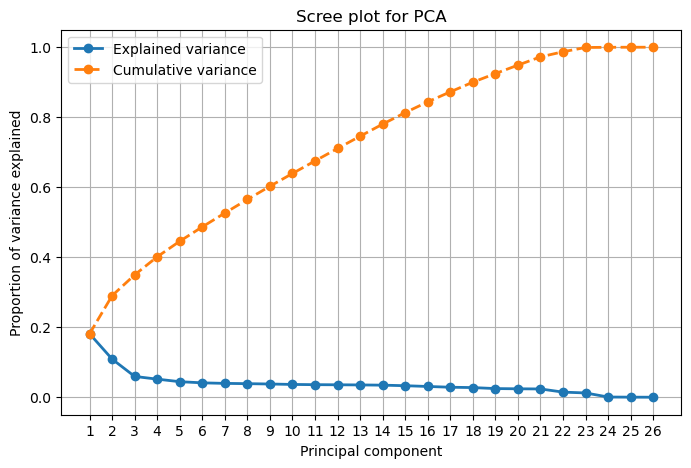

In [29]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

scaler_test = StandardScaler()
X_train_feat_numeric_scaled = pd.DataFrame(
    scaler_test.fit_transform(X_train_feat[numeric_cols]),
    columns=numeric_cols,
    index=X_train_feat.index
)


pca_full = PCA()
pca_full.fit_transform(X_train_feat_numeric_scaled)
# Scree plot and cumulative explained variance
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(evr) + 1), evr, 'o-', linewidth=2, label='Explained variance')
plt.plot(range(1, len(evr) + 1), cum, 'o--', linewidth=2, label='Cumulative variance')
plt.xticks(range(1, len(evr) + 1))
plt.xlabel('Principal component')
plt.ylabel('Proportion of variance explained')
plt.title('Scree plot for PCA')
plt.grid(True)
plt.legend()
plt.show()

In [36]:
X_valid_feat_numeric_scaled = pd.DataFrame(
    scaler_test.transform(X_valid_feat[numeric_cols]),
    columns=numeric_cols,
    index=X_valid_feat.index
)


In [31]:
pca_final = PCA(n_components=18)
X_train_numeric_reduced = pca_final.fit_transform(X_train_feat_numeric_scaled)
total_kept = pca_final.explained_variance_ratio_.sum()
print(f"\nOriginal dimensionality: {X_train_feat_numeric_scaled.shape[1]}")
print(f"Reduced dimensionality: {X_train_numeric_reduced.shape[1]}")
print(f"Total variance kept: {total_kept*100:.2f}%")


Original dimensionality: 26
Reduced dimensionality: 18
Total variance kept: 90.01%


In [37]:
X_valid_numeric_reduced = pca_final.transform(X_valid_feat_numeric_scaled)


In [39]:
X_train_numeric_reduced_df = pd.DataFrame(X_train_numeric_reduced)
X_valid_numeric_reduced_df = pd.DataFrame(X_valid_numeric_reduced)

In [66]:
X_train_pca_feat = pd.concat([X_train_numeric_reduced_df, X_train_feat[categorical_cols + boolean_cols]],axis=1)
X_valid_pca_feat = pd.concat([X_valid_numeric_reduced_df, X_valid_feat[categorical_cols + boolean_cols]],axis=1)
X_train_pca_feat.columns = X_train_pca_feat.columns.astype(str)
X_valid_pca_feat.columns = X_valid_pca_feat.columns.astype(str)

In [68]:
X_train_pca_feat["0"]

0       -0.617053
1       -0.607159
2       -0.452651
3       -0.831344
4       -0.598961
           ...   
30499   -0.710983
30500   -0.008216
30501   -0.794061
30502   -0.602859
30503   -0.170600
Name: 0, Length: 30504, dtype: float64

In [69]:
pca_cols = [f"{i}" for i in range(18)] 

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols),
        ("pca", "passthrough", pca_cols),  # already scaled and transformed
        ("bool", "passthrough", boolean_cols),  # make sure these are float
    ],
    sparse_threshold=1.0,
)

# --------------------
# Baseline Model: Isolation Forest
# --------------------
model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline([("prep", preprocess), ("clf", model)])

# Train on normal only
pipe.fit(X_train_pca_feat)

# Score validation
# IsolationForest: higher score_samples = more normal
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid_pca_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")


AP: 0.1258
AUC-ROC : 0.5169


In [70]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
pipe_lof = Pipeline([("prep", preprocess), ("clf", lof)])
pipe_lof.fit(X_train_pca_feat)

# Score validation
# ILocal Outlier Factor: higher score_samples = more normal
scores_normal = pipe_lof["clf"].score_samples(pipe_lof["prep"].transform(X_valid_pca_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1370
AUC-ROC : 0.5491


In [71]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(
    kernel="rbf",     # RBF works well for non-linear anomalies
    nu=0.05,          # Upper bound on fraction of anomalies in training set
    gamma="scale"     # Kernel coefficient (can tune)
)


pipe = Pipeline([("prep", preprocess), ("clf", model)])

# Train on normal only
pipe.fit(X_train_pca_feat)

# Score validation
# OneClassSVM: higher score_samples = more normal
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid_pca_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

# # Sample Output CSV
# out_df = pd.DataFrame({"index": process_ids_valid, "anomaly_score": anom_score})
# out_df.to_csv("valid_pred.csv", index=False)
# print("Wrote valid_pred.csv")

AP: 0.1408
AUC-ROC : 0.5563


In [20]:
X_train_feat

,OccupancyStatus,Channel,ProductType,PropertyType,LoanPurpose,ProgramIndicator,PropertyValMethod,BalloonIndicator,CreditScore,MI_Pct,NumberOfUnits,OriginalCLTV,OriginalDTI,OriginalUPB,OriginalLTV,OriginalInterestRate,OriginalLoanTerm,NumberOfBorrowers,0_1_UPB_Diff,1_2_UPB_Diff,2_3_UPB_Diff,3_4_UPB_Diff,4_5_UPB_Diff,5_6_UPB_Diff,6_7_UPB_Diff,7_8_UPB_Diff,8_9_UPB_Diff,9_10_UPB_Diff,10_11_UPB_Diff,11_12_UPB_Diff,12_13_UPB_Diff,UPB_std,UPB_trend,UPB_range,FirstTimeHomebuyerFlag,SuperConformingFlag,CreditScore_is_outlier,OriginalDTI_is_outlier
0,P,R,FRM,MH,P,Unknown,2,Unknown,747,0,1,67,26,82000,67,8.000,360,1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.552585,0.071554,0.072084,0.072615,0.073159,0.073705,0.074251,338.358025,-809.13,809.13,False,False,True,True
1,P,R,FRM,SF,P,Unknown,2,Unknown,659,0,1,68,32,305000,68,7.875,360,2,0.0,0.327869,0.000000,0.000000,0.000000,0.000000,0.236270,0.072926,0.073461,0.073997,0.074537,0.075082,0.075632,986.892356,-3067.28,3067.28,False,False,True,True
2,I,R,FRM,SF,C,Unknown,2,Unknown,775,0,2,70,15,154000,70,7.625,360,2,0.0,0.000000,0.000000,0.649351,0.000000,0.000000,0.021556,0.098936,0.099663,0.100397,0.101141,0.101886,0.102634,697.977300,-1955.58,1955.58,False,False,True,True
3,P,R,FRM,SF,P,H,2,N,815,25,1,88,49,51000,88,7.250,360,1,0.0,0.000000,1.960784,0.000000,0.000000,0.000000,-0.619060,0.086027,0.086619,0.000000,0.174961,0.088422,0.089039,390.097853,-954.09,1000.00,True,False,True,True
4,P,R,FRM,SF,C,Unknown,2,Unknown,772,0,1,69,41,155000,69,7.750,360,1,0.0,0.000000,0.000000,0.645161,0.000000,0.000000,-0.068032,0.074741,0.075278,0.000000,0.075822,0.076374,0.076920,548.918499,-1478.61,1478.61,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30499,I,C,FRM,SF,N,Unknown,2,Unknown,709,0,1,80,32,268000,80,8.125,360,2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.244337,0.068902,0.069420,0.069938,0.070461,0.070989,0.071518,684.624916,-1772.34,1772.34,False,False,True,True
30500,P,R,FRM,PU,P,Unknown,2,Unknown,782,0,1,28,50,314000,28,6.125,360,1,0.0,0.318471,0.000000,0.000000,0.319489,0.000000,0.054276,0.101420,0.102043,0.102668,0.103298,0.103933,0.104573,1321.311201,-4091.30,4091.30,False,False,True,True
30501,P,R,FRM,SF,P,H,2,Unknown,669,0,1,80,36,60000,80,7.000,360,1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.583967,0.085885,0.086462,0.087024,0.087621,0.088202,0.088802,273.192097,-662.26,662.26,True,False,True,True
30502,P,R,FRM,SF,P,Unknown,2,N,741,30,1,95,41,517000,95,5.875,360,1,0.0,0.193798,0.000000,0.000000,0.194175,0.000000,0.192525,0.213062,0.107543,0.000000,0.108185,0.108832,0.219505,2247.566725,-6862.33,6862.33,False,False,True,True
